# Police KNN estimation

In [38]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [39]:
input_path       = "data/processed/28714514_2021UKCensus_processed_20251009001rs.parquet"
latent_path      = "scratch/ukc2021-proc20251009001rs__aemose-4-4_e7x3_s192-128-96-64_sage128_g0-64-32-g1-32-16_b512_20260517124211/ukc2021-proc20251009001rs__aemose-4-4_e7x3_s192-128-96-64_sage128_g0-64-32-g1-32-16_b512_20260517124211__ep1381-st516868__latent.parquet"
oa_index_path    = "data/pyg/ukc2021-proc20251009001rs__oa_index.parquet"
oac_path         = "data/2021OAC/uk_oac_final.csv"
police_data_path = "data/police-uk/police-2025-ew-knn-k10-polygon.parquet"
lad_path         = "data/spatial/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv"

## Load data

### AE-MoSE

In [40]:
latent_df = pd.read_parquet(latent_path)
latent_df = latent_df[latent_df.index.str.startswith("E") | latent_df.index.str.startswith("W")].copy()

aemose_exp_df = latent_df[["top_expert_name"]].copy()

latent_df.drop(columns=["index", "train_valid_test", "EXR_entropy", "top_expert_index", "top_group_index", "top_expert_name"], inplace=True)
latent_df.drop(columns=[col for col in latent_df.columns if col.startswith("EXR_")], inplace=True)
latent_df.shape

(188880, 64)

In [41]:
latent_df.index = latent_df.index.astype(str)
latent_df.head()

,EMB_000,EMB_001,EMB_002,EMB_003,EMB_004,EMB_005,EMB_006,EMB_007,EMB_008,EMB_009,...,EMB_054,EMB_055,EMB_056,EMB_057,EMB_058,EMB_059,EMB_060,EMB_061,EMB_062,EMB_063
OA,,,,,,,,,,,,,,,,,,,,,
E00071085,10.088778,-1.554822,1.773867,-3.237351,3.665862,-0.389270,5.771652,-0.436632,-12.981589,-0.628472,...,-4.925622,-6.133627,12.885193,-2.031326,-2.367699,1.344938,-5.750841,-9.652271,-17.059050,4.214541
E00177567,9.779602,-4.120526,3.127157,-1.140632,4.270104,0.594318,6.138867,1.075725,-12.327974,-2.621850,...,-6.603142,-5.034491,15.211015,-2.087036,-5.251964,1.579664,-5.949459,-13.703210,-15.752306,3.387438
E00039966,10.403625,-1.787578,1.591250,-0.229739,5.158608,1.238132,5.078167,1.336170,-12.249456,-2.426197,...,-3.915088,-7.226249,15.026868,-1.462750,-3.926569,1.445843,-6.046395,-7.380721,-15.996258,4.066959
E00155752,8.337117,-2.521118,3.724571,-1.342207,4.092932,-1.148114,6.089904,-1.506464,-14.459101,-0.628764,...,-6.791752,-5.565237,17.579281,-2.173002,-3.481239,0.945997,-6.627783,-10.578916,-14.520760,3.819246
E00018981,10.438596,-3.673077,3.873389,-0.859429,3.960541,-2.933431,5.054089,-0.405975,-12.600612,-1.394906,...,-3.552574,-5.086481,12.409743,-3.197866,-0.473380,-0.075073,-5.717663,-13.710186,-17.667255,2.775856


In [42]:
aemose_exp_df.index = aemose_exp_df.index.astype(str)
aemose_exp_df.head()

,top_expert_name
OA,
E00071085,3_10
E00177567,5_16
E00039966,3_09
E00155752,6_20
E00018981,0_02


In [43]:
print(f"latent_df NaN count: {latent_df.isnull().sum().sum()}")

latent_df NaN count: 0


### Train, validation, test split

In [44]:
oa_index = pd.read_parquet(oa_index_path)
oa_index.drop(columns=["index"], inplace=True)
oa_index.set_index("OA", inplace=True)
oa_index.head()

,train_valid_test
OA,
E00071085,train
E00177567,valid
E00039966,test
E00155752,train
E00018981,train


In [45]:
oa_train = oa_index[oa_index["train_valid_test"] == "train"].copy()
oa_valid = oa_index[oa_index["train_valid_test"] == "valid"].copy()
oa_test  = oa_index[oa_index["train_valid_test"] == "test"].copy()
print(f"oa_train: {oa_train.shape}, oa_valid: {oa_valid.shape}, oa_test: {oa_test.shape}")

oa_train: (191219, 1), oa_valid: (23902, 1), oa_test: (23902, 1)


### Input vars used to train AE-MoSE

In [46]:
input_df = pd.read_parquet(input_path)
input_df = input_df[input_df.index.str.startswith("E") | input_df.index.str.startswith("W")].copy()
input_df.head()

,uk001002_ntot_clipd_minmax,uk002002_ntot_noout_minmax,uk002003_ntot_noout_minmax,uk002004_ntot_clipd_minmax,uk002005_ntot_noout_minmax,uk002006_ntot_clipd_minmax,uk003002_ntot_noout_minmax,uk003003_ntot_noout_minmax,uk003005_ntot_noout_minmax,uk003006_ntot_noout_minmax,...,uk030005_ntot_clipd_ihs_minmax,uk030006_ntot_clipd_ihs_minmax,uk046004_ntot_clipd_ihs_minmax,uk046005_ntot_clipd_ihs_minmax,uk046009_ntot_clipd_ihs_minmax,uk046010_ntot_clipd_ihs_minmax,uk061006_ntot_clipd_ihs_minmax,uk062010_ntot_clipd_ihs_minmax,uk066008_ntot_clipd_ihs_minmax,uk066016_ntot_noout_ihs_minmax
OA,,,,,,,,,,,,,,,,,,,,,
E00071085,1.000000,0.305556,0.572115,0.068917,0.215650,0.072985,0.152113,0.611111,0.814389,0.693878,...,0.000000,0.223937,0.427451,0.146423,0.000000,0.000000,0.000000,0.523080,0.478946,0.507327
E00177567,1.000000,0.633985,0.321839,0.050698,0.079320,0.032214,0.264544,0.166667,0.614839,0.666667,...,0.661007,0.356224,0.642472,0.428904,0.000000,0.609488,0.375846,0.509519,0.455178,0.626352
E00039966,1.000000,0.308138,0.661796,0.024641,0.121163,0.020876,0.172855,0.266667,0.827428,0.821918,...,0.000000,0.362560,0.000000,0.384673,0.000000,0.000000,0.000000,0.532128,0.340561,0.581545
E00155752,0.469484,0.400431,0.475673,0.109099,0.202043,0.059420,0.365070,0.222222,0.574783,0.724138,...,0.402945,0.073309,0.211627,0.683376,0.000000,0.307746,0.000000,0.566563,0.237234,0.685577
E00018981,1.000000,0.251574,0.710547,0.060628,0.054204,0.089890,0.175998,0.666667,0.715518,0.747126,...,0.827517,0.782768,0.000000,0.146423,0.699728,0.208073,0.176281,0.581465,0.289491,0.651806


### 2021 OAC

In [47]:
oac_df = pd.read_csv(oac_path)
oac_df["GeographyCode"] = oac_df["GeographyCode"].astype(str)
oac_df.rename(columns={"GeographyCode": "OA"}, inplace=True)
oac_df.set_index("OA", inplace=True)
oac_df = oac_df[oac_df.index.str.startswith("E") | oac_df.index.str.startswith("W")].copy()

### Plice UK Data

In [48]:
police_df = pd.read_parquet(police_data_path)
police_df = np.log1p(police_df)
police_df.index = police_df.index.astype(str)
police_df.shape

(188880, 14)

In [49]:
police_df.head()

,Violence and sexual offences,Criminal damage and arson,Public order,Vehicle crime,Anti-social behaviour,Burglary,Other theft,Drugs,Possession of weapons,Shoplifting,Robbery,Bicycle theft,Other crime,Theft from the person
OA,,,,,,,,,,,,,,
E00000001,2.859618,4.051950,2.859618,5.132131,4.309107,4.301962,3.063094,4.711179,6.159542,5.011055,5.044384,2.966522,5.358091,2.859618
E00000003,4.073913,4.477482,4.433110,4.732572,4.157099,4.556724,4.217175,4.541355,6.176604,5.276346,5.139907,4.126382,5.453955,4.086019
E00000005,4.011546,4.416049,4.592605,3.820825,3.808147,4.567248,3.943688,3.863826,6.147256,5.348898,5.123273,3.086116,5.401473,0.215332
E00000007,1.148019,3.387475,2.826770,1.877099,4.352591,2.846224,0.000000,2.465905,5.709116,1.895222,3.625760,1.889405,4.413673,0.000000
E00000010,2.503479,4.523832,4.518901,4.964296,4.361440,3.234961,3.306222,2.445026,5.947909,5.243585,4.598822,3.656136,5.670523,3.416374


In [50]:
police_df.describe()

,Violence and sexual offences,Criminal damage and arson,Public order,Vehicle crime,Anti-social behaviour,Burglary,Other theft,Drugs,Possession of weapons,Shoplifting,Robbery,Bicycle theft,Other crime,Theft from the person
count,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000,188880.000000
mean,2.133111,4.616619,4.818443,5.171984,3.756886,5.451960,4.908250,5.716371,6.666236,5.714290,6.692654,6.982116,5.917370,7.034398
std,2.161470,1.797467,1.780219,1.770760,2.259836,1.503043,1.662801,1.672372,1.206574,1.887801,1.578776,1.413348,1.201298,1.607297
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.765400,4.000638,4.165378,2.494871,4.635538,4.148395,4.825308,5.892983,5.044153,5.738883,6.142108,5.202542,6.269701
50%,1.929267,4.639595,4.849834,5.149236,3.973235,5.406991,4.964241,5.721462,6.517854,5.870297,6.628421,6.923394,5.779302,7.151082
75%,3.629533,5.500703,5.687846,6.154416,5.014542,6.206041,5.734155,6.659311,7.381379,6.615039,7.795166,7.969574,6.485268,8.153438
max,8.563402,9.431858,10.600238,10.790639,9.708931,10.625047,9.382497,10.722273,10.838707,10.144192,10.999497,10.975941,10.651292,10.998469


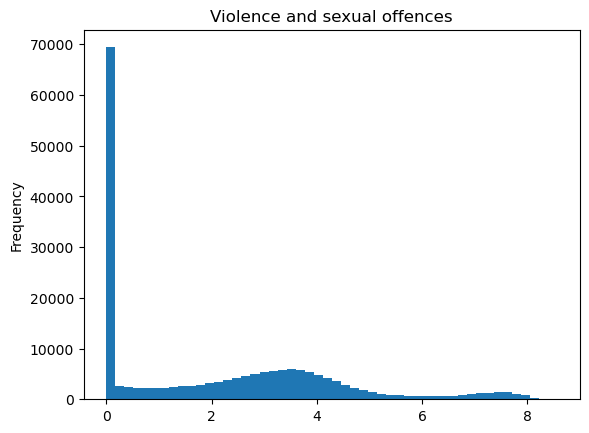

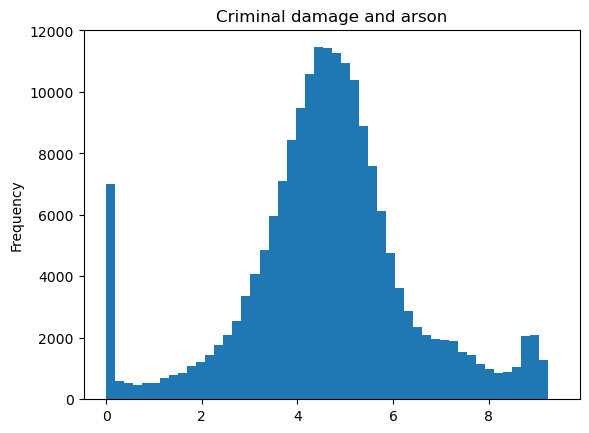

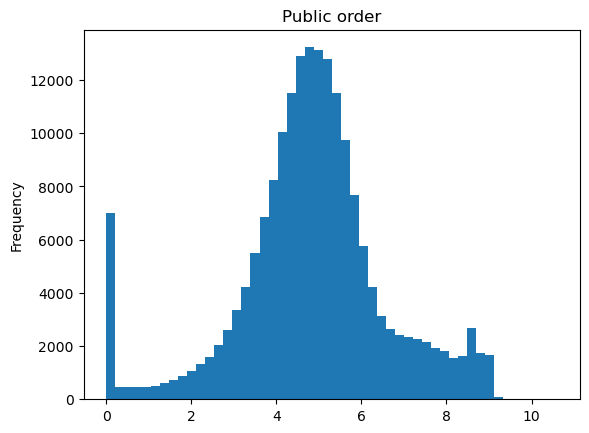

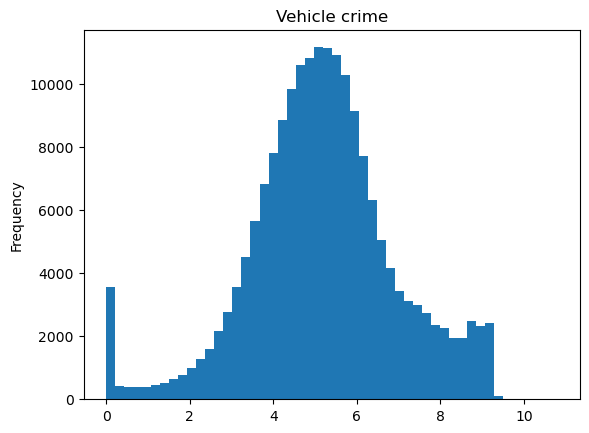

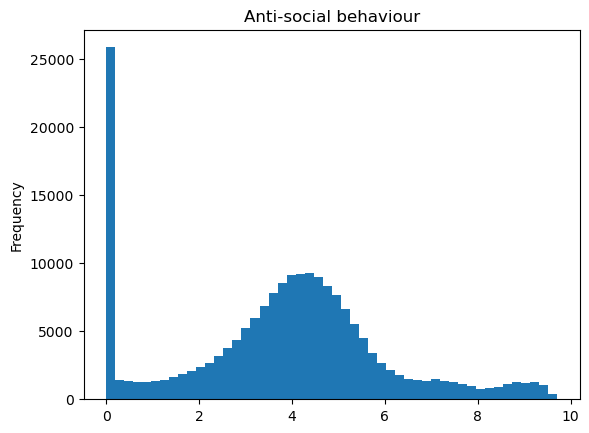

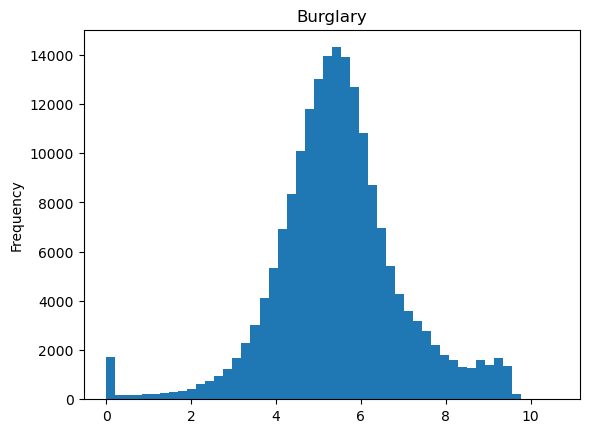

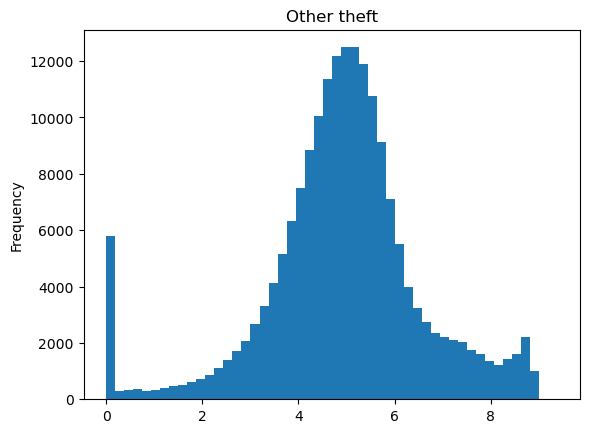

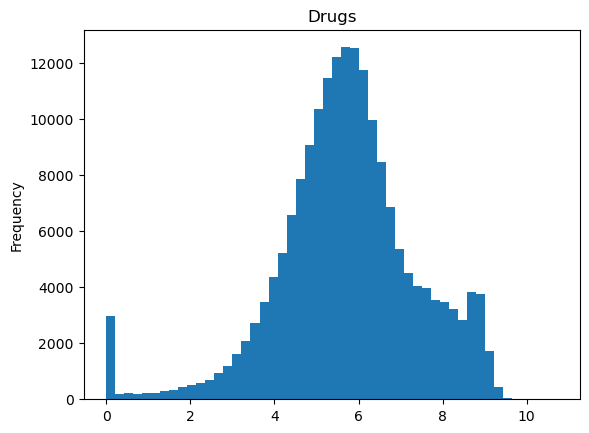

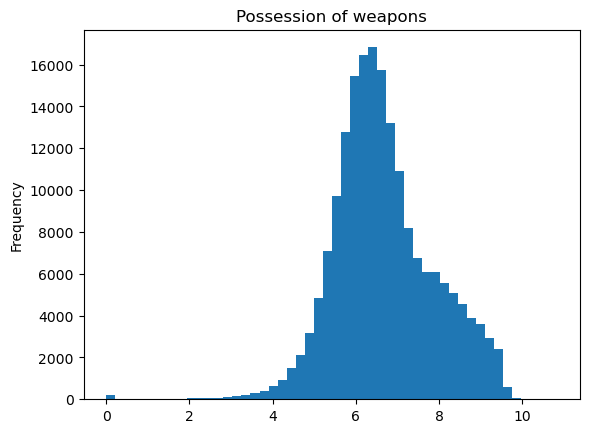

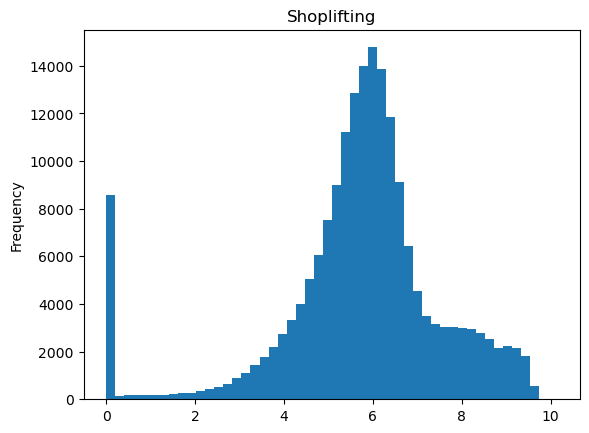

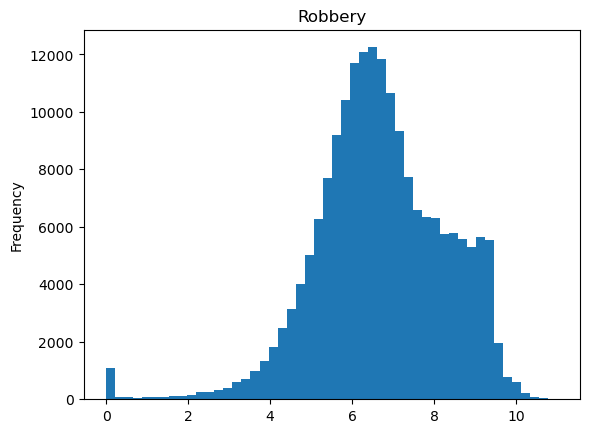

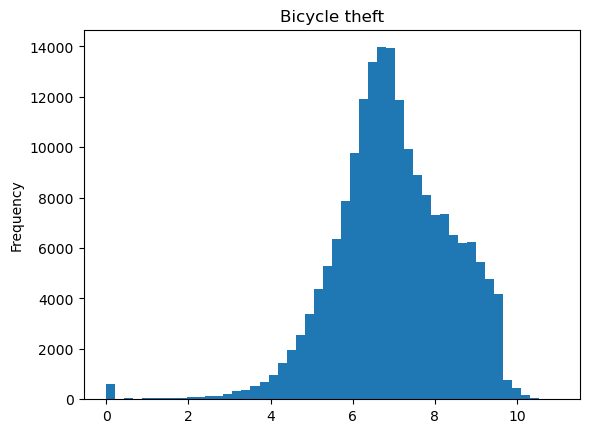

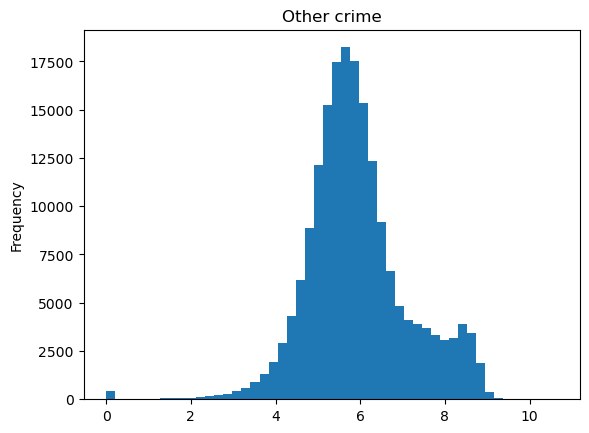

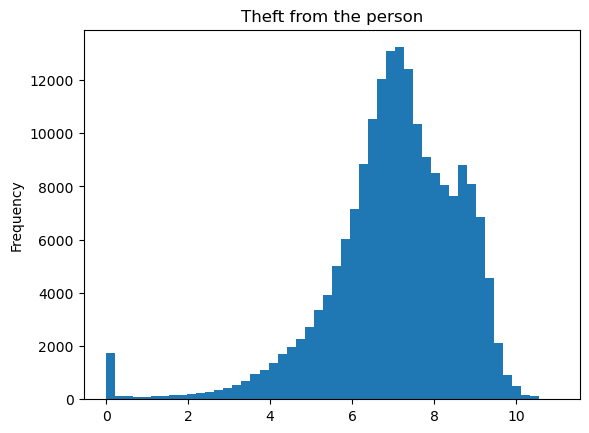

In [51]:
for col in police_df.columns:
    police_df[col].plot.hist(bins=50)
    plt.title(col)
    plt.ylabel("Frequency")
    plt.show()

In [52]:
assert set(latent_df.index.to_list()) == set(police_df.index.to_list()), "Mismatching OAs!"

## Averages per class

## Baseline: 2021 OAC supergroup, group, subgroup

In [53]:
train_oac = oa_train.join(oac_df, how="inner").join(police_df, how="inner").drop(columns=["train_valid_test"]).copy()
test_oac  = oa_test.join(oac_df, how="inner").join(police_df, how="inner").drop(columns=["train_valid_test"]).copy()

print(f"train_oac: {train_oac.shape}, test_oac: {test_oac.shape}")

train_oac.head()

train_oac: (151160, 19), test_oac: (18977, 19)


,LAD25Code,LAD25Name,Supergroup,Group,Subgroup,Violence and sexual offences,Criminal damage and arson,Public order,Vehicle crime,Anti-social behaviour,Burglary,Other theft,Drugs,Possession of weapons,Shoplifting,Robbery,Bicycle theft,Other crime,Theft from the person
OA,,,,,,,,,,,,,,,,,,,
E00071085,E06000019,"Herefordshire, County of",2,2b,2b2,1.997998,4.826323,5.101436,6.192705,4.787241,5.748027,5.360314,5.981547,6.657732,5.614439,6.644651,6.021918,5.940217,6.785921
E00155752,E07000210,Mole Valley,6,6b,6b1,0.000000,0.000000,3.891056,4.048090,3.312413,4.940629,4.924936,5.363330,6.185969,5.561880,7.932755,7.269960,5.088135,7.828651
E00018981,E09000026,Redbridge,5,5b,5b2,3.466849,5.900499,5.929528,3.582298,5.136753,5.087245,5.029629,5.900498,6.656607,6.444373,6.064956,6.365727,6.251388,6.240516
E00109187,E07000069,Castle Point,2,2b,2b1,3.255602,5.336273,5.191516,5.328470,5.587656,5.968388,4.943318,5.522028,6.158398,6.848229,7.188715,7.005199,5.560458,7.577619
E00116122,E07000089,Hart,1,1c,1c1,4.127287,5.934964,4.903541,6.016189,5.238136,6.126557,5.597364,6.972195,6.716529,6.426345,8.055881,7.282976,5.953795,8.153038


In [54]:
oac_sup_means  = train_oac.groupby("Supergroup")[police_df.columns].mean()
oac_grp_means  = train_oac.groupby("Group")[police_df.columns].mean()
oac_sub_means  = train_oac.groupby("Subgroup")[police_df.columns].mean()

In [55]:
oac_sup_pred = test_oac[["Supergroup"]].merge(oac_sup_means, left_on="Supergroup", right_index=True, how="left")
oac_sup_pred.set_index(test_oac.index, inplace=True)
oac_grp_pred = test_oac[["Group"]].merge(oac_grp_means, left_on="Group", right_index=True, how="left")
oac_grp_pred.set_index(test_oac.index, inplace=True)
oac_sub_pred = test_oac[["Subgroup"]].merge(oac_sub_means, left_on="Subgroup", right_index=True, how="left")
oac_sub_pred.set_index(test_oac.index, inplace=True)

In [56]:
rows = []
for j, name in enumerate(police_df.columns):
    yt, yp = test_oac[name].values, oac_sup_pred[name].values
    rows.append({
        "category": name,
        "mse":  mean_squared_error(yt, yp),
        "rmse": np.sqrt(mean_squared_error(yt, yp)),
        "mae":  mean_absolute_error(yt, yp),
        "r2":   r2_score(yt, yp),
    })
oac_sup_metrics = pd.DataFrame(rows).set_index("category").sort_values("r2", ascending=False)
print("overall mean R^2:", oac_sup_metrics["r2"].mean())
oac_sup_metrics[["r2", "mae", "rmse"]].round(3)

overall mean R^2: 0.23981287539535498


,r2,mae,rmse
category,,,
Theft from the person,0.473,0.862,1.173
Robbery,0.372,0.937,1.253
Bicycle theft,0.343,0.856,1.144
Drugs,0.289,1.006,1.408
Vehicle crime,0.267,1.083,1.519
Other theft,0.235,1.003,1.461
Possession of weapons,0.228,0.795,1.058
Burglary,0.216,0.929,1.338
Public order,0.180,1.137,1.617


In [57]:
rows = []
for j, name in enumerate(police_df.columns):
    yt, yp = test_oac[name].values, oac_grp_pred[name].values
    rows.append({
        "category": name,
        "mse":  mean_squared_error(yt, yp),
        "rmse": np.sqrt(mean_squared_error(yt, yp)),
        "mae":  mean_absolute_error(yt, yp),
        "r2":   r2_score(yt, yp),
    })
oac_grp_metrics = pd.DataFrame(rows).set_index("category").sort_values("r2", ascending=False)
print("overall mean R^2:", oac_grp_metrics["r2"].mean())
oac_grp_metrics[["r2", "mae", "rmse"]].round(3)

overall mean R^2: 0.26271629459611484


,r2,mae,rmse
category,,,
Theft from the person,0.498,0.834,1.145
Robbery,0.400,0.903,1.224
Bicycle theft,0.374,0.828,1.117
Drugs,0.310,0.979,1.387
Vehicle crime,0.291,1.056,1.494
Possession of weapons,0.253,0.770,1.040
Other theft,0.252,0.985,1.444
Burglary,0.235,0.913,1.321
Public order,0.201,1.115,1.596


In [58]:
rows = []
for j, name in enumerate(police_df.columns):
    yt, yp = test_oac[name].values, oac_sub_pred[name].values
    rows.append({
        "category": name,
        "mse":  mean_squared_error(yt, yp),
        "rmse": np.sqrt(mean_squared_error(yt, yp)),
        "mae":  mean_absolute_error(yt, yp),
        "r2":   r2_score(yt, yp),
    })
oac_sub_metrics = pd.DataFrame(rows).set_index("category").sort_values("r2", ascending=False)
print("overall mean R^2:", oac_sub_metrics["r2"].mean())
oac_sub_metrics[["r2", "mae", "rmse"]].round(3)

overall mean R^2: 0.2834418569619143


,r2,mae,rmse
category,,,
Theft from the person,0.528,0.813,1.109
Robbery,0.424,0.885,1.199
Bicycle theft,0.399,0.812,1.095
Drugs,0.336,0.963,1.361
Vehicle crime,0.311,1.045,1.472
Possession of weapons,0.272,0.760,1.027
Other theft,0.272,0.973,1.425
Burglary,0.253,0.906,1.305
Public order,0.219,1.101,1.578


## Evaluation: average per AEMoSE classes/experts

In [59]:
train_aemose = oa_train.join(aemose_exp_df, how="inner").join(police_df, how="inner").drop(columns=["train_valid_test"]).copy()
test_aemose  = oa_test.join(aemose_exp_df, how="inner").join(police_df, how="inner").drop(columns=["train_valid_test"]).copy()

print(f"train_aemose: {train_aemose.shape}, test_aemose: {test_aemose.shape}")

train_aemose.head()

train_aemose: (151160, 15), test_aemose: (18977, 15)


,top_expert_name,Violence and sexual offences,Criminal damage and arson,Public order,Vehicle crime,Anti-social behaviour,Burglary,Other theft,Drugs,Possession of weapons,Shoplifting,Robbery,Bicycle theft,Other crime,Theft from the person
OA,,,,,,,,,,,,,,,
E00071085,3_10,1.997998,4.826323,5.101436,6.192705,4.787241,5.748027,5.360314,5.981547,6.657732,5.614439,6.644651,6.021918,5.940217,6.785921
E00155752,6_20,0.000000,0.000000,3.891056,4.048090,3.312413,4.940629,4.924936,5.363330,6.185969,5.561880,7.932755,7.269960,5.088135,7.828651
E00018981,0_02,3.466849,5.900499,5.929528,3.582298,5.136753,5.087245,5.029629,5.900498,6.656607,6.444373,6.064956,6.365727,6.251388,6.240516
E00109187,3_10,3.255602,5.336273,5.191516,5.328470,5.587656,5.968388,4.943318,5.522028,6.158398,6.848229,7.188715,7.005199,5.560458,7.577619
E00116122,0_01,4.127287,5.934964,4.903541,6.016189,5.238136,6.126557,5.597364,6.972195,6.716529,6.426345,8.055881,7.282976,5.953795,8.153038


In [60]:
aemose_means  = train_aemose.groupby("top_expert_name")[police_df.columns].mean()

In [61]:
aemose_pred = test_aemose[["top_expert_name"]].merge(aemose_means, left_on="top_expert_name", right_index=True, how="left")
aemose_pred.set_index(test_aemose.index, inplace=True)

In [62]:
rows = []
for j, name in enumerate(police_df.columns):
    yt, yp = test_aemose[name].values, aemose_pred[name].values
    rows.append({
        "category": name,
        "mse":  mean_squared_error(yt, yp),
        "rmse": np.sqrt(mean_squared_error(yt, yp)),
        "mae":  mean_absolute_error(yt, yp),
        "r2":   r2_score(yt, yp),
    })
aemose_metrics = pd.DataFrame(rows).set_index("category").sort_values("r2", ascending=False)
print("overall mean R^2:", aemose_metrics["r2"].mean())
aemose_metrics[["r2", "mae", "rmse"]].round(3)

overall mean R^2: 0.28727516879060794


,r2,mae,rmse
category,,,
Theft from the person,0.548,0.792,1.086
Robbery,0.437,0.866,1.186
Bicycle theft,0.403,0.803,1.091
Drugs,0.339,0.950,1.358
Vehicle crime,0.323,1.027,1.460
Other theft,0.277,0.962,1.420
Possession of weapons,0.277,0.750,1.024
Burglary,0.265,0.885,1.296
Other crime,0.223,0.745,1.059


## Linear ridge regression

In [63]:
X_in_train = oa_train.join(input_df, how="inner").drop(columns=["train_valid_test"]).copy()
X_in_val   = oa_valid.join(input_df, how="inner").drop(columns=["train_valid_test"]).copy()
X_in_test  = oa_test.join( input_df, how="inner").drop(columns=["train_valid_test"]).copy()

X_train = oa_train.join(latent_df, how="inner").drop(columns=["train_valid_test"]).copy()
X_val   = oa_valid.join(latent_df, how="inner").drop(columns=["train_valid_test"]).copy()
X_test  = oa_test.join( latent_df, how="inner").drop(columns=["train_valid_test"]).copy()

y_train = oa_train.join(police_df, how="inner").drop(columns=["train_valid_test"]).copy()
y_val   = oa_valid.join(police_df, how="inner").drop(columns=["train_valid_test"]).copy()
y_test  = oa_test.join( police_df, how="inner").drop(columns=["train_valid_test"]).copy()

print(f"X_in_train: {X_in_train.shape}, X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_in_val: {X_in_val.shape}, X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_in_test: {X_in_test.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

X_in_train: (151160, 171), X_train: (151160, 64), y_train: (151160, 14)
X_in_val: (18743, 171), X_val: (18743, 64), y_val: (18743, 14)
X_in_test: (18977, 171), X_test: (18977, 64), y_test: (18977, 14)


In [64]:
assert set(X_in_train.index.to_list()) == set(y_train.index.to_list()), "Mismatching OAs!"
assert set(X_in_val.index.to_list()) == set(y_val.index.to_list()), "Mismatching OAs!"
assert set(X_in_test.index.to_list()) == set(y_test.index.to_list()), "Mismatching OAs!"
assert set(X_train.index.to_list()) == set(y_train.index.to_list()), "Mismatching OAs!"
assert set(X_val.index.to_list()) == set(y_val.index.to_list()), "Mismatching OAs!"
assert set(X_test.index.to_list()) == set(y_test.index.to_list()), "Mismatching OAs!"

In [65]:
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test, y_test], axis=1)
print(f"train_df: {train_df.shape}, test_df: {test_df.shape}")

train_df: (151160, 78), test_df: (18977, 78)


### Baseline: linear regression on input vars

In [66]:
from sklearn.linear_model import RidgeCV

# scaler = StandardScaler().fit(X_train)
# X_train_s = scaler.transform(X_train).astype(np.float32)
# X_test_s  = scaler.transform(X_test ).astype(np.float32)

input_lin = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=10).fit(X_in_train, y_train)
# input_lin = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=10).fit(X_in_slctd_train, y_slctd_train)
print("best alpha:", input_lin.alpha_)


best alpha: 0.1


In [67]:
input_lin_pred = input_lin.predict(X_in_test)
# input_lin_pred = input_lin.predict(X_in_slctd_test)
print("probe pred shape:", input_lin_pred.shape)

probe pred shape: (18977, 14)


In [68]:
rows = []
for j, name in enumerate(police_df.columns):
    yt, yp = y_test[name].values, input_lin_pred[:, j]
    # yt, yp = y_slctd_test[name].values, input_lin_pred[:, j]
    rows.append({
        "category": name,
        "mse":  mean_squared_error(yt, yp),
        "rmse": np.sqrt(mean_squared_error(yt, yp)),
        "mae":  mean_absolute_error(yt, yp),
        "r2":   r2_score(yt, yp),
    })
input_pred_metrics = pd.DataFrame(rows).set_index("category").sort_values("r2", ascending=False)
print("overall mean R^2 (linear probe on embeddings):", input_pred_metrics["r2"].mean())
input_pred_metrics[["r2", "mae", "rmse"]].round(3)

overall mean R^2 (linear probe on embeddings): 0.41845529463889874


,r2,mae,rmse
category,,,
Theft from the person,0.668,0.674,0.932
Robbery,0.562,0.757,1.046
Bicycle theft,0.551,0.687,0.946
Drugs,0.466,0.853,1.221
Possession of weapons,0.438,0.655,0.903
Vehicle crime,0.428,0.946,1.342
Other theft,0.401,0.889,1.292
Other crime,0.377,0.668,0.948
Burglary,0.373,0.831,1.197


### Evaluation: linear probe on embeddings

In [69]:
from sklearn.linear_model import RidgeCV

# scaler = StandardScaler().fit(X_train)
# X_train_s = scaler.transform(X_train).astype(np.float32)
# X_test_s  = scaler.transform(X_test ).astype(np.float32)

probe_lin = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=10).fit(X_train, y_train)
# probe_lin = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=10).fit(X_slctd_train, y_slctd_train)
print("best alpha:", probe_lin.alpha_)


best alpha: 100.0


In [70]:
probe_lin_pred = probe_lin.predict(X_test)
# probe_lin_pred = probe_lin.predict(X_slctd_test)
print("probe pred shape:", probe_lin_pred.shape)

probe pred shape: (18977, 14)


In [71]:
rows = []
for j, name in enumerate(police_df.columns):
    yt, yp = y_test[name].values, probe_lin_pred[:, j]
    # yt, yp = y_slctd_test[name].values, probe_lin_pred[:, j]
    rows.append({
        "category": name,
        "mse":  mean_squared_error(yt, yp),
        "rmse": np.sqrt(mean_squared_error(yt, yp)),
        "mae":  mean_absolute_error(yt, yp),
        "r2":   r2_score(yt, yp),
    })
probe_metrics = pd.DataFrame(rows).set_index("category").sort_values("r2", ascending=False)
print("overall mean R^2 (linear probe on embeddings):", probe_metrics["r2"].mean())
probe_metrics[["r2", "mae", "rmse"]].round(3)

overall mean R^2 (linear probe on embeddings): 0.3870328564981523


,r2,mae,rmse
category,,,
Theft from the person,0.634,0.708,0.977
Robbery,0.527,0.782,1.087
Bicycle theft,0.506,0.721,0.992
Drugs,0.438,0.870,1.253
Possession of weapons,0.401,0.671,0.932
Vehicle crime,0.395,0.964,1.380
Other theft,0.373,0.902,1.322
Public order,0.345,1.002,1.445
Other crime,0.343,0.679,0.973


## Compare

In [72]:
# --- Updated side-by-side comparison: model vs linear probe vs OAC subgroup vs constant ---
compare = pd.DataFrame({
    "r2_aemose_exp": aemose_metrics["r2"],
    "r2_oac_grp":    oac_grp_metrics["r2"],
    "r2_oac_sub":    oac_sub_metrics["r2"],
    "r2_oac_sup":    oac_sup_metrics["r2"],
    "r2_lin_probe":  probe_metrics["r2"],
    "r2_lin_input":  input_pred_metrics["r2"],
})
compare = compare.sort_index()
compare.round(3)

,r2_aemose_exp,r2_oac_grp,r2_oac_sub,r2_oac_sup,r2_lin_probe,r2_lin_input
category,,,,,,
Anti-social behaviour,0.195,0.177,0.198,0.157,0.274,0.299
Bicycle theft,0.403,0.374,0.399,0.343,0.506,0.551
Burglary,0.265,0.235,0.253,0.216,0.339,0.373
Criminal damage and arson,0.191,0.184,0.202,0.167,0.310,0.342
Drugs,0.339,0.310,0.336,0.289,0.438,0.466
Other crime,0.223,0.194,0.212,0.166,0.343,0.377
Other theft,0.277,0.252,0.272,0.235,0.373,0.401
Possession of weapons,0.277,0.253,0.272,0.228,0.401,0.438
Public order,0.220,0.201,0.219,0.180,0.345,0.369


In [73]:
compare.reset_index(inplace=True)

compare["category"] = compare["category"].str.replace("Anti-social behaviour", "Anti-social behav.")
compare["category"] = compare["category"].str.replace("Criminal damage and arson", "CD&A")
compare["category"] = compare["category"].str.replace("Possession of weapons", "Poss. of weapons")
compare["category"] = compare["category"].str.replace("Theft from the person", "Theft from the pers.")
compare["category"] = compare["category"].str.replace("Violence and sexual offences", "VSO")

compare.rename(columns={
    "category": "Category",
    "r2_aemose_exp": "AEMoSE exp",
    "r2_oac_grp": "OAC grp",
    "r2_oac_sub": "OAC sub",
    "r2_oac_sup": "OAC sup",
    "r2_lin_probe": "AEMoSE emb",
    "r2_lin_input": "input var",
    }, inplace=True)

# compare.to_csv("eval/police_knn_estimate.csv", index=False)
compare

,Category,AEMoSE exp,OAC grp,OAC sub,OAC sup,AEMoSE emb,input var
0,Anti-social behav.,0.195492,0.176954,0.198018,0.157348,0.274396,0.298786
1,Bicycle theft,0.402529,0.374452,0.398503,0.343487,0.506326,0.551382
2,Burglary,0.264503,0.234983,0.253265,0.215994,0.339491,0.372522
3,CD&A,0.191077,0.183730,0.201880,0.166963,0.309531,0.341521
4,Drugs,0.339270,0.310086,0.335711,0.289297,0.437508,0.465765
5,Other crime,0.222838,0.194030,0.212098,0.165855,0.343131,0.377312
6,Other theft,0.276770,0.251837,0.272028,0.234630,0.373395,0.401114
7,Poss. of weapons,0.276539,0.253077,0.272235,0.227925,0.400777,0.437577
8,Public order,0.220144,0.201209,0.218956,0.179524,0.345195,0.368888
9,Robbery,0.436987,0.400295,0.424371,0.371650,0.526763,0.562066


In [74]:
compare.to_latex("eval/police_knn_estimate.tex", index=False)